____
# Drifters acceleration outliers



In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, U
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon
from diagnosis import dataset_coloc_combs, DRIFTER, ALTI, WD, prepared_wd, plot_exemple

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

_______
# Data

In [2]:
DRIFTER.keys(), ALTI.keys(), WD.keys()
# wd_depth = '0' or '15'
# ggd_var = 'etaf', 'etac', 'adtf', 'adtc', 'fromduacsv'

(dict_keys(['nofilter', '0.5cpd', '1.5cpd', '2.5cpd', '3cpd']),
 dict_keys(['swot250naive', 'swot250gauss1e3', 'swot250gauss2e3', 'swot250gauss3e3', 'swot250gauss4e3', 'swot250gauss5e3', 'swot2kmnaive', 'swot2kmgauss1e3', 'swot2kmgauss2e3', 'swot2kmgauss3e3', 'swot2kmgauss4e3', 'swot2kmgauss5e3', 'swot2kmgauss1e4']),
 dict_keys(['era5']))

In [3]:
#dfef = pd.read_csv(os.path.join(zarr_dir, 'editing_flags_250m.csv')).set_index('row_number')
#dfc = pd.read_csv(ALTI['swot250naive'])[['row_number', 'cvl_distance_to_coast']].set_index('row_number')

#dfa = pd.concat([dfef, dfc], axis=1)
#dsa = dfa.to_xarray()
comb_list = [dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='0'),
            dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='15')]

DS = dataset_coloc_combs(comb_list, nearest =False)
DSS = DS.where(DS.depth==0, drop=True).isel(id_comb=0)
DSD = DS.where(DS.depth==15, drop=True).isel(id_comb=1)


#df = xr.merge([DSS.isel(id_comb=0), dsa]).to_dataframe()

nofilter__swot2kmnaive_etaf__rio_0era5
nofilter__swot2kmnaive_etaf__rio_15era5


__________________
# PB = Some Lagrangian and coriolis acceleration outliers

In [4]:
df = DS.isel(id_comb=0).to_dataframe()
#df =df/np.sqrt(U2)

In [5]:
# SELECT OUTLIERS

df290 = df.where(df.drifter_id =='290').dropna()
df460 = df.where(df.drifter_id =='300534064300460').dropna()
df675 = df.where(df.drifter_id =='0-4388675').dropna()

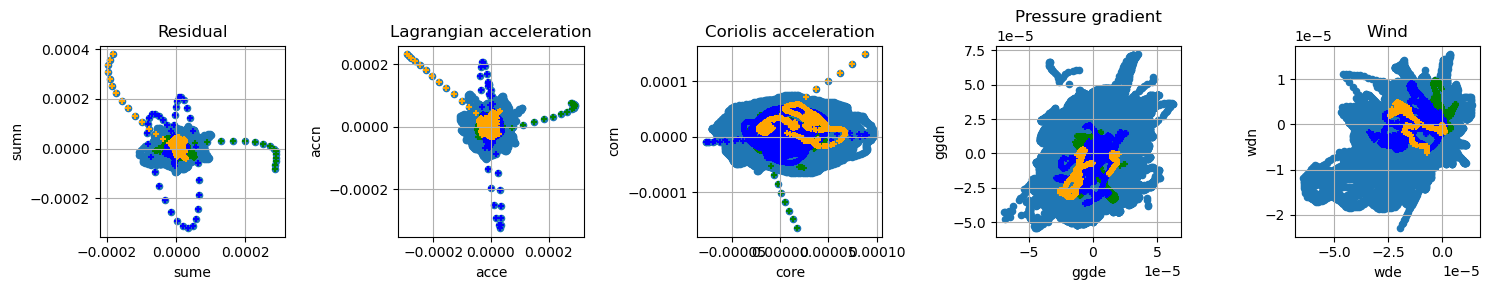

In [7]:
fig, axs = plt.subplots(1, 5, figsize=(15, 3))
axs = axs.flatten()
ax=axs[0]
df.plot.scatter('sume', 'sumn', ax=ax)
df290.plot.scatter('sume', 'sumn', ax=ax, c='g', marker='+')
df460.plot.scatter('sume', 'sumn', ax=ax, c='b', marker='+')
df675.plot.scatter('sume', 'sumn', ax=ax, c='orange', marker='+')
ax.set_title('Residual')

ax=axs[1]
df.plot.scatter('acce', 'accn', ax=ax)
df290.plot.scatter('acce', 'accn', ax=ax, c='g', marker='+')
df460.plot.scatter('acce', 'accn', ax=ax, c='b', marker='+')
df675.plot.scatter('acce', 'accn', ax=ax, c='orange', marker='+')
ax.set_title('Lagrangian acceleration')

ax=axs[2]
df.plot.scatter('core', 'corn', ax=ax)
df290.plot.scatter('core', 'corn', ax=ax, c='g', marker='+')
df460.plot.scatter('core', 'corn', ax=ax, c='b', marker='+')
df675.plot.scatter('core', 'corn', ax=ax, c='orange', marker='+')
ax.set_title('Coriolis acceleration')

ax=axs[3]
df.plot.scatter('ggde', 'ggdn', ax=ax)
df290.plot.scatter('ggde', 'ggdn', ax=ax, c='g', marker='+')
df460.plot.scatter('ggde', 'ggdn', ax=ax, c='b', marker='+')
df675.plot.scatter('ggde', 'ggdn', ax=ax, c='orange', marker='+')
ax.set_title('Pressure gradient')

ax=axs[4]
df.plot.scatter('wde', 'wdn', ax=ax)
df290.plot.scatter('wde', 'wdn', ax=ax, c='g', marker='+')
df460.plot.scatter('wde', 'wdn', ax=ax, c='b', marker='+')
df675.plot.scatter('wde', 'wdn', ax=ax, c='orange', marker='+')
ax.set_title('Wind')


for ax in axs :
    ax.grid()

fig.tight_layout()


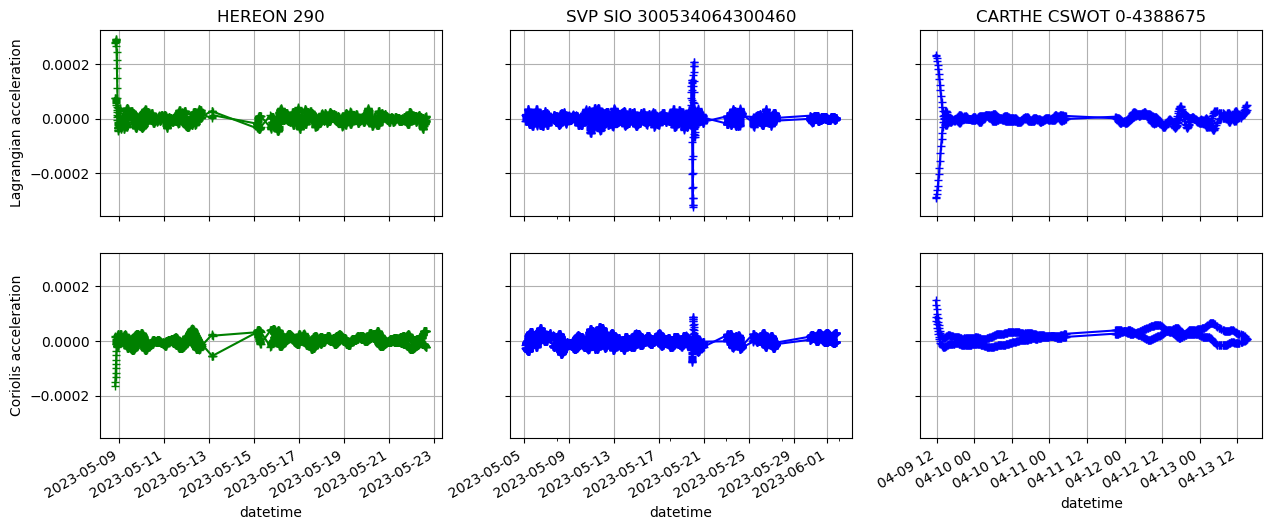

In [8]:
fig, axs = plt.subplots(2, 3, figsize=(15, 6), sharey=True, sharex='col')
axs = axs.flatten()
ax=axs[0]
df290.dropna().set_index('datetime').acce.plot(ax=ax, c='g', marker='+')
df290.dropna().set_index('datetime').accn.plot(ax=ax, c='g', marker='+')
ax.set_title('HEREON 290')
ax=axs[1]
df460.dropna().set_index('datetime').acce.plot(ax=ax, c='b', marker='+')
df460.dropna().set_index('datetime').accn.plot(ax=ax, c='b', marker='+')
ax.set_title('SVP SIO 300534064300460')
ax=axs[2]
df675.dropna().set_index('datetime').acce.plot(ax=ax, c='b', marker='+')
df675.dropna().set_index('datetime').accn.plot(ax=ax, c='b', marker='+')
ax.set_title('CARTHE CSWOT 0-4388675')

ax=axs[3]
df290.dropna().set_index('datetime').core.plot(ax=ax, c='g', marker='+')
df290.dropna().set_index('datetime').corn.plot(ax=ax, c='g', marker='+')
ax=axs[4]
df460.dropna().set_index('datetime').core.plot(ax=ax, c='b', marker='+')
df460.dropna().set_index('datetime').corn.plot(ax=ax, c='b', marker='+')
ax=axs[5]
df675.dropna().set_index('datetime').core.plot(ax=ax, c='b', marker='+')
df675.dropna().set_index('datetime').corn.plot(ax=ax, c='b', marker='+')


for ax in axs :
    ax.grid()

for ax in axs[0:3] :
    ax.set_ylabel('Lagrangian acceleration')
for ax in axs[3:] :
    ax.set_ylabel('Coriolis acceleration')



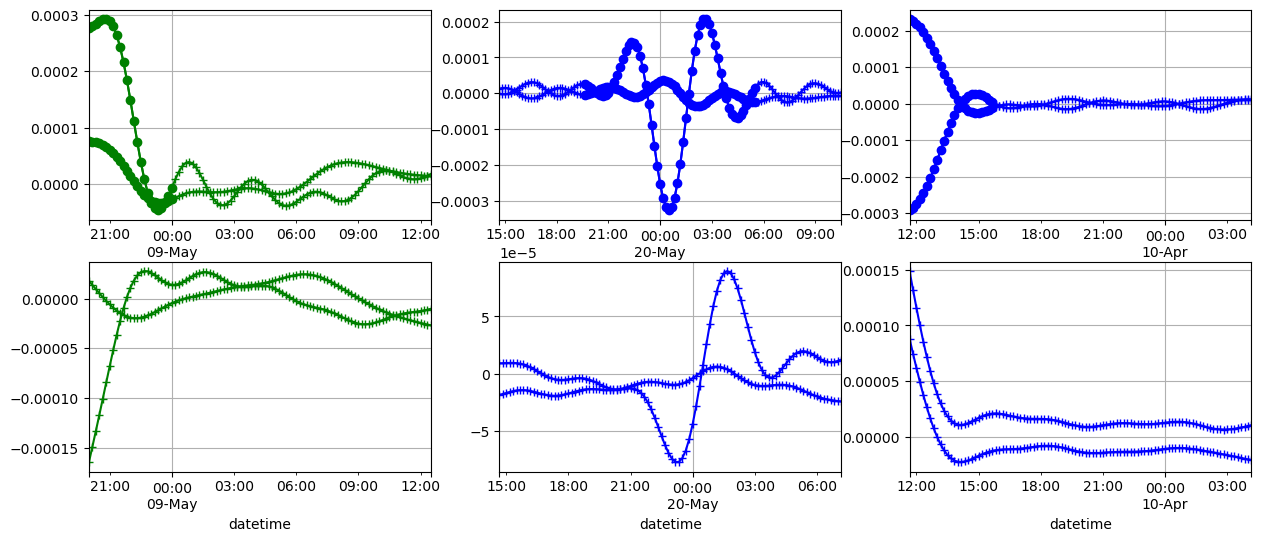

In [9]:
fig, axs = plt.subplots(2, 3, figsize=(15, 6))
axs = axs.flatten()
ax=axs[0]
df290.iloc[0:100].dropna().set_index('datetime').acce.plot(ax=ax, c='g', marker='+')
df290.iloc[0:100].dropna().set_index('datetime').accn.plot(ax=ax, c='g', marker='+')
df290.iloc[0:25].dropna().set_index('datetime').acce.plot(ax=ax, c='g', marker='o')
df290.iloc[0:25].dropna().set_index('datetime').accn.plot(ax=ax, c='g', marker='o')
ax=axs[1]
i=2050
df460.iloc[i:i+120].dropna().set_index('datetime').acce.plot(ax=ax, c='b', marker='+')
df460.iloc[i:i+120].dropna().set_index('datetime').accn.plot(ax=ax, c='b', marker='+')
df460.iloc[i+30:i+90].dropna().set_index('datetime').acce.plot(ax=ax, c='b', marker='o')
df460.iloc[i+30:i+90].dropna().set_index('datetime').accn.plot(ax=ax, c='b', marker='o')
ax=axs[2]
df675.iloc[0:100].dropna().set_index('datetime').acce.plot(ax=ax, c='b', marker='+')
df675.iloc[0:100].dropna().set_index('datetime').accn.plot(ax=ax, c='b', marker='+')
df675.iloc[0:25].dropna().set_index('datetime').acce.plot(ax=ax, c='b', marker='o')
df675.iloc[0:25].dropna().set_index('datetime').accn.plot(ax=ax, c='b', marker='o')


ax=axs[3]
df290.iloc[0:100].dropna().set_index('datetime').core.plot(ax=ax, c='g', marker='+')
df290.iloc[0:100].dropna().set_index('datetime').corn.plot(ax=ax, c='g', marker='+')

ax=axs[4]
df460.iloc[i:i+100].dropna().set_index('datetime').core.plot(ax=ax, c='b', marker='+')
df460.iloc[i:i+100].dropna().set_index('datetime').corn.plot(ax=ax, c='b', marker='+')
ax=axs[5]
df675.iloc[0:100].dropna().set_index('datetime').core.plot(ax=ax, c='b', marker='+')
df675.iloc[0:100].dropna().set_index('datetime').corn.plot(ax=ax, c='b', marker='+')


for ax in axs :
    ax.grid()

In [19]:
i=2050
df290[0:25].index

Index([295158, 295159, 295160, 295161, 295162, 295163, 295164, 295165, 295166,
       295167, 295168, 295169, 295170, 295171, 295172, 295173, 295174, 295175,
       295176, 295177, 295178, 295179, 295180, 295181, 295182],
      dtype='int64', name='row_number')

In [106]:
err_acc = [175606, 175607, 175608, 175609, 175610, 175611, 175612, 175613, 175614,
       175615, 175616, 175617, 175618, 175619, 175620, 175621, 175622, 175623,
       175624, 175625, 175626, 175627, 175628, 175629, 175630, 175631, 175632,
       175633, 175634, 175635, 175636, 175637, 175638, 175639, 175640, 175641,
       175642, 175643, 175644, 175645, 175646, 175647, 175648, 175649, 175650,
       175651, 175652, 175653, 175654, 175655, 175656, 175657, 175658, 175659,
       175660, 175661, 175662, 175663, 175664, 175665] + [14980, 14981, 14982, 14983, 14984, 14985, 14986, 14987, 14988, 14989,
       14990, 14991, 14992, 14993, 14994, 14995, 14996, 14997, 14998, 14999,
       15000, 15001, 15002, 15003, 15004] + [295158, 295159, 295160, 295161, 295162, 295163, 295164, 295165, 295166,
       295167, 295168, 295169, 295170, 295171, 295172, 295173, 295174, 295175,
       295176, 295177, 295178, 295179, 295180, 295181, 295182]

In [123]:
DSc = DS.drop_sel(row_number = err_acc)

In [124]:
# https://visu-drifter.mio.osupytheas.fr/Application_Shiny_R/


# Check Raw trajectories
https://visu-drifter.mio.osupytheas.fr/Application_Shiny_R/
Some outliers are not well removed in the L1

# Correction

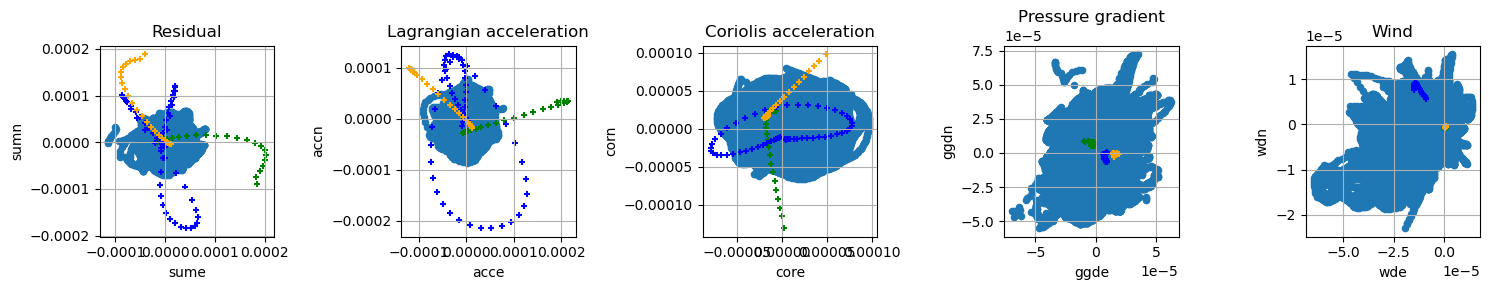

In [128]:
DScorrected = DS.drop_sel(row_number = err_acc)
dfcorrected = DScorrected.isel(id_comb=0).to_dataframe()

fig, axs = plt.subplots(1, 5, figsize=(15, 3))
axs = axs.flatten()
ax=axs[0]
dfcorrected.plot.scatter('sume', 'sumn', ax=ax)
df290.iloc[0:25].plot.scatter('sume', 'sumn', ax=ax, c='g', marker='+')
df460.iloc[i+30:i+90].plot.scatter('sume', 'sumn', ax=ax, c='b', marker='+')
df675.iloc[0:25].plot.scatter('sume', 'sumn', ax=ax, c='orange', marker='+')
dfggd.plot.scatter('sume', 'sumn', ax=ax, c='magenta', marker='+')
ax.set_title('Residual')

ax=axs[1]
dfcorrected.plot.scatter('acce', 'accn', ax=ax)
df290.iloc[0:25].plot.scatter('acce', 'accn', ax=ax, c='g', marker='+')
df460.iloc[i+30:i+90].plot.scatter('acce', 'accn', ax=ax, c='b', marker='+')
df675.iloc[0:25].plot.scatter('acce', 'accn', ax=ax, c='orange', marker='+')
dfggd.plot.scatter('acce', 'accn', ax=ax, c='magenta', marker='+')
ax.set_title('Lagrangian acceleration')

ax=axs[2]
dfcorrected.plot.scatter('core', 'corn', ax=ax)
df290.iloc[0:25].plot.scatter('core', 'corn', ax=ax, c='g', marker='+')
df460.iloc[i+30:i+90].plot.scatter('core', 'corn', ax=ax, c='b', marker='+')
df675.iloc[0:25].plot.scatter('core', 'corn', ax=ax, c='orange', marker='+')
ax.set_title('Coriolis acceleration')

ax=axs[3]
dfcorrected.plot.scatter('ggde', 'ggdn', ax=ax)
df290.iloc[0:25].plot.scatter('ggde', 'ggdn', ax=ax, c='g', marker='+')
df460.iloc[i+30:i+90].plot.scatter('ggde', 'ggdn', ax=ax, c='b', marker='+')
df675.iloc[0:25].plot.scatter('ggde', 'ggdn', ax=ax, c='orange', marker='+')
ax.set_title('Pressure gradient')

ax=axs[4]
dfcorrected.plot.scatter('wde', 'wdn', ax=ax)
df290.iloc[0:25].plot.scatter('wde', 'wdn', ax=ax, c='g', marker='+')
df460.iloc[i+30:i+90].plot.scatter('wde', 'wdn', ax=ax, c='b', marker='+')
df675.iloc[0:25].plot.scatter('wde', 'wdn', ax=ax, c='orange', marker='+')
ax.set_title('Wind')


for ax in axs :
    ax.grid()

fig.tight_layout()